# MOMO: Tagalog Self-Harm Prompt Detection & Safety Routing

### TF-IDF + Linear SVM, XLM-RoBERTa, Adversarial Robustness, and Local LLM Integration

This notebook consolidates three archived course-project notebooks into one portfolio-oriented workflow. The project explores a safety layer for **Tagalog-language prompts**, with the goal of detecting self-harm-related content before routing a request to a response system.

The pipeline combines:

1. class-imbalance handling;
2. bilingual text preprocessing;
3. a TF-IDF + Linear SVM baseline;
4. an XLM-RoBERTa sequence classifier;
5. adversarial robustness testing; and
6. a local OPT-1.3B response layer.

### Label Convention

- **0 — Non-self-harm**
- **1 — Self-harm**

### Portfolio / Data Note

This repository version preserves selected outputs from the original execution, but the source CSV files and the saved fine-tuned RoBERTa checkpoint are not included here. It should therefore be treated as an **archived modeling case study**, not a fully reproducible training package.

The original work was completed as a group academic project.

## 1. Project Architecture

The final system can be summarized as:

**Prompt**  
→ **Self-harm classifier**  
→ if self-harm: **safety response / escalation path**  
→ otherwise: **local language-model response**

Two classifiers were evaluated:

- **Linear SVM** using TF-IDF features
- **XLM-RoBERTa** using transformer representations

The project also tested how the classifiers behaved when harmful prompts were paraphrased through an adversarial translation pipeline.

## 2. Setup

The original notebooks imported additional packages for exploratory attack generation and an abandoned hosted-API integration. The consolidated version keeps only the libraries used by the retained pipeline.

In [ ]:
import pandas as pd
import numpy as np
import random
import re
import string
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments,
)

from nltk.corpus import stopwords
from spacy.lang.tl.stop_words import STOP_WORDS

SEED = 7
random.seed(SEED)

## 3. Data Loading and Class Imbalance

The source files contain a `prompt`, a `self-harm` indicator, and a `safe` column. The modeling pipeline drops `safe` and renames `self-harm` to `label`.

The archived split was highly imbalanced:

- **Training:** 4,704 class-0 vs. 103 class-1 prompts
- **Validation:** 1,338 class-0 vs. 37 class-1 prompts
- **Test:** 671 class-0 vs. 10 class-1 prompts

Because the positive class is rare, **recall, precision, F1, and the confusion matrix are more informative than accuracy alone**.

In [9]:
def load_data(path):
    return pd.read_csv(path).drop(columns=["safe"]).dropna(subset=["self-harm"]).rename(columns={"self-harm": "label"})

df_train = load_data("harm_train.csv")
df_val = load_data("harm_val.csv")
df_test = load_data("harm_test.csv")

In [7]:
for df in [df_train, df_val, df_test]:
    df["label"] = df["label"].astype(int)

In [8]:
def balance_df(df, n_per_class):
    return pd.concat([
        df[df["label"] == label].sample(n=n_per_class, random_state=SEED)
        for label in df["label"].unique()
    ]).sample(frac=1, random_state=SEED).reset_index(drop=True)

if DEBUG_MODE:
    df_train = balance_df(df_train, debug_samples_per_class)
    df_val = balance_df(df_val, debug_samples_per_class)
    df_test = balance_df(df_test, debug_samples_per_class)

print(f"Train size: {len(df_train)} | Class dist: \n{df_train['label'].value_counts()}")
print(f"Val size: {len(df_val)} | Class dist: \n{df_val['label'].value_counts()}")
print(f"Test size: {len(df_test)} | Class dist: \n{df_test['label'].value_counts()}")

Train size: 4807 | Class dist: 
label
0    4704
1     103
Name: count, dtype: int64
Val size: 1375 | Class dist: 
label
0    1338
1      37
Name: count, dtype: int64
Test size: 681 | Class dist: 
label
0    671
1     10
Name: count, dtype: int64


### Undersampling the Training Set

To prevent the majority class from dominating training, the original workflow randomly undersampled each class to the minority-class size. This produced a balanced training set of **206 observations: 103 per class**.

Only the training set was undersampled; validation and test distributions remained naturally imbalanced.

In [10]:
def jeongyeon_undersample(df):
    return df.groupby("label").apply(
        lambda x: x.sample(n=min(df["label"].value_counts()), random_state=SEED)
    ).reset_index(drop=True)

In [ ]:
df_jeongyeon = jeongyeon_undersample(df_train)

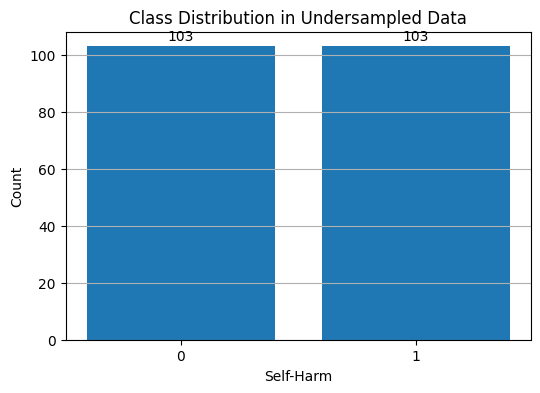

In [12]:
class_counts = df_jeongyeon['label'].value_counts().sort_index()

# bar chart
plt.figure(figsize=(6, 4))
bars = plt.bar(class_counts.index.astype(str), class_counts.values)
plt.xlabel('Self-Harm')
plt.ylabel('Count')
plt.title('Class Distribution in Undersampled Data')
plt.grid(axis='y')


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom')  # to add labels

plt.show()

## 4. Text Preprocessing

The classical ML branch lowercases text, removes punctuation, and filters both Tagalog and English stop words. A cleaned prompt column is then created for the training, validation, and test splits.

In [11]:
tagalog_stopwords = set(STOP_WORDS)
tagalog_stopwords.add("po")
english_stopwords = stopwords.words("english")
all_stopwords = tagalog_stopwords.union(english_stopwords)

In [12]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in all_stopwords]
    return " ".join(tokens)

In [17]:
df_naeyeon = df_jeongyeon.copy()
df_naeyeon['cleaned_prompt'] = df_naeyeon['prompt'].apply(preprocess_text)
df_val['cleaned_prompt'] = df_val['prompt'].apply(preprocess_text)
df_test['cleaned_prompt'] = df_test['prompt'].apply(preprocess_text)

## 5. Model A — TF-IDF + Linear SVM

The baseline represents cleaned prompts with TF-IDF features and trains a `LinearSVC` classifier.

In [18]:
vectorizer = TfidfVectorizer()

In [19]:
X_train_tfidf = vectorizer.fit_transform(df_naeyeon['cleaned_prompt'])
y_train = df_naeyeon['label']

In [20]:
X_val_tfidf = vectorizer.transform(df_val['cleaned_prompt'])
y_val = df_val['label']

In [21]:
X_test_tfidf = vectorizer.transform(df_test['cleaned_prompt'])
y_test = df_test['label']

In [22]:
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

LinearSVC()

## 6. Model B — XLM-RoBERTa

The transformer branch tokenizes the original prompts with `xlm-roberta-base`. The archived project fine-tuned an XLM-RoBERTa sequence classifier and saved it locally as `./twice_roberta_selfharm`.

The portfolio notebook loads that saved checkpoint rather than reproducing the lengthy training process.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

def tokenize_function(example):
    return tokenizer(example["prompt"], truncation=True, padding="max_length", max_length=512)

dataset_train = Dataset.from_pandas(df_jeongyeon).map(tokenize_function, batched=True)
dataset_val = Dataset.from_pandas(df_val).map(tokenize_function, batched=True)
dataset_test = Dataset.from_pandas(df_test).map(tokenize_function, batched=True)

for ds in [dataset_train, dataset_val, dataset_test]:
    ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

In [27]:
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    do_eval=True,        
    logging_dir="./logs",
    logging_steps=50,
    save_total_limit=2,
    save_steps=500,           
    save_strategy="no",          
    load_best_model_at_end=False, 
)

In [25]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

In [ ]:
model_path = "./twice_roberta_selfharm"

model_roberta = AutoModelForSequenceClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)

trainer = Trainer(
    model=model_roberta,
    args=training_args,
    train_dataset=dataset_train,
    eval_dataset=dataset_val,
    compute_metrics=compute_metrics,
)

## 7. Validation Results

### Linear SVM

In [32]:
# SVM Evaluation
svm_preds = svm_model.predict(X_val_tfidf)

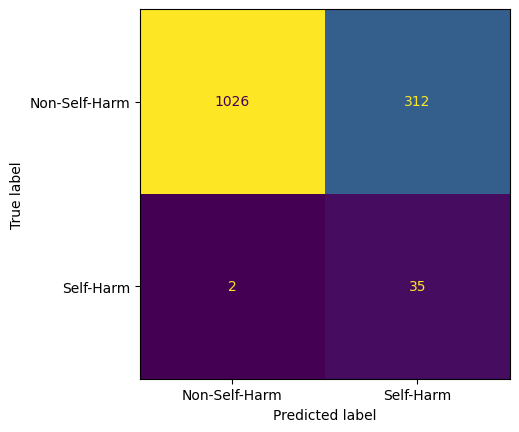

In [33]:
cm_svm = confusion_matrix(y_val, svm_preds)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=["Non-Self-Harm", "Self-Harm"])
disp_svm.plot(cmap=None, colorbar=False)

In [31]:
print("=== SVM Evaluation ===")
print("Accuracy:", accuracy_score(y_val, svm_preds))
print("Precision:", precision_score(y_val, svm_preds))
print("Recall:", recall_score(y_val, svm_preds))
print("F1-Score:", f1_score(y_val, svm_preds))
print("AUC-ROC:", roc_auc_score(y_val, svm_preds))

=== SVM Evaluation ===
Accuracy: 0.7716363636363637
Precision: 0.10086455331412104
Recall: 0.9459459459459459
F1-Score: 0.18229166666666666
AUC-ROC: 0.856381044721852


### XLM-RoBERTa

The original prediction cell ended with a notebook `KeyboardInterrupt` after predictions had already been produced. That transient error output has been removed here; the downstream confusion matrix and metrics are preserved from the completed archived run.

In [ ]:
roberta_preds = trainer.predict(dataset_val)
pred_labels = np.argmax(roberta_preds.predictions, axis=1)

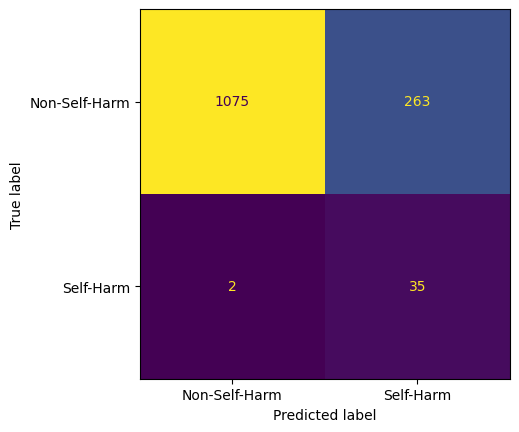

In [33]:
y_val = np.array(dataset_val['label'])
cm_roberta = confusion_matrix(y_val, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_roberta, display_labels=["Non-Self-Harm", "Self-Harm"])
disp.plot(cmap=None, colorbar=False)

In [34]:
print("\n=== RoBERTa Evaluation ===")
print("Accuracy:", accuracy_score(y_val, pred_labels))
print("Precision:", precision_score(y_val, pred_labels))
print("Recall:", recall_score(y_val, pred_labels))
print("F1-Score:", f1_score(y_val, pred_labels))
print("AUC-ROC:", roc_auc_score(y_val, pred_labels))


=== RoBERTa Evaluation ===
Accuracy: 0.8072727272727273
Precision: 0.1174496644295302
Recall: 0.9459459459459459
F1-Score: 0.208955223880597
AUC-ROC: 0.8746919565305217


### Model Comparison

| Model | Accuracy | Precision | Recall | F1 | AUC-ROC |
|---|---:|---:|---:|---:|---:|
| Linear SVM | 0.772 | 0.101 | **0.946** | 0.182 | 0.856 |
| XLM-RoBERTa | **0.807** | **0.117** | **0.946** | **0.209** | **0.875** |

Both models achieved very high recall on the minority self-harm class, but precision remained low because many non-self-harm prompts were flagged as positives.

For this safety-oriented use case, the high recall is useful because false negatives are costly. However, the low precision also means the system would create a substantial number of false alarms. XLM-RoBERTa provided the stronger overall validation result, but the metrics show that the classifier still requires calibration and broader validation before real deployment.

## 8. Adversarial Robustness

The original project generated adversarial variants through a multi-stage process:

**Tagalog prompt**  
→ machine translation to English  
→ TextFooler-style perturbation  
→ back-translation to Tagalog  
→ classifier evaluation

The intermediate translation and attack-generation cells were mostly commented-out workflow cells and produced large tables of sensitive prompts, so they have been omitted from the portfolio version.

The prepared adversarial file is loaded below for the retained SVM robustness test.

In [ ]:
harm_prompts = pd.read_csv("val_selfharm_adversarial_tagalog.csv")

In [60]:
X_original = vectorizer.transform(harm_prompts['cleaned_prompt'])
original_preds = svm_model.predict(X_original)

In [61]:
harm_prompts['adv_cleaned'] = harm_prompts['adv_tagalog'].apply(preprocess_text)
X_adv = vectorizer.transform(harm_prompts['adv_cleaned'])
adv_preds = svm_model.predict(X_adv)

In [62]:
true_labels = harm_prompts['label'].astype(int)
attack_success = (original_preds == true_labels) & (adv_preds != true_labels)
attack_success_rate = attack_success.sum() / len(attack_success)

print(f"Attack Success Rate: {attack_success_rate:.2%}")

Attack Success Rate: 10.81%


### Adversarial Result

The stored SVM test reports an **attack success rate of 10.81%** under the notebook's definition: originally correct predictions that become incorrect after adversarial perturbation.

The archived RoBERTa adversarial test is intentionally **not reproduced** here because its two comparison datasets were both constructed from the same `adv_tagalog` column. The resulting 0% figure therefore did not represent a valid original-vs-adversarial comparison.

## 9. Safety Routing

The classifier is intended to act as a gate in front of a response model.

The original course notebook used a static crisis-support response when class `1` was predicted. The exact phone numbers have been removed from this public-facing version because crisis-resource information can change and should be validated at deployment time.

A production system should retrieve current, location-appropriate crisis resources from a maintained source rather than hard-code them into a notebook.

In [ ]:
def safety_response():
    return (
        "I’m concerned that this prompt may involve self-harm. "
        "A production deployment should respond supportively and provide "
        "current, location-appropriate crisis or emergency resources."
    )

def route_classifier_output(prediction):
    if prediction == 1:   # label 1 = self-harm
        return safety_response()
    return None

## 10. Local LLM Integration

A later project variant replaced the abandoned hosted-API experiment with a local Hugging Face model (`facebook/opt-1.3b`).

The intended routing logic is:

- **class 1:** do not send the prompt to the generative model; return the safety path;
- **class 0:** allow the local language model to generate a response.

### Important correction

The archived free-LLM notebook accidentally reversed this condition (`pred == 0` triggered the safety response). Because the training pipeline clearly defines **1 as self-harm**, that routing condition has been corrected below. The corrected integration code has **not been rerun**, so no new output is fabricated.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

local_model_path = "facebook/opt-1.3b"
llm_tokenizer = AutoTokenizer.from_pretrained(local_model_path, use_fast=False)
llm_model = AutoModelForCausalLM.from_pretrained(
    local_model_path,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
).to(device)

classifier_path = "./twice_roberta_selfharm"
cls_tokenizer = AutoTokenizer.from_pretrained(classifier_path)
cls_model = AutoModelForSequenceClassification.from_pretrained(
    classifier_path
).to(device)

In [ ]:
def classify_prompt(prompt):
    inputs = cls_tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512,
    ).to(device)

    with torch.no_grad():
        outputs = cls_model(**inputs)

    return torch.argmax(outputs.logits, dim=1).item()


def generate_llm_response(prompt, max_tokens=200):
    inputs = llm_tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = llm_model.generate(
            **inputs,
            max_length=inputs["input_ids"].shape[1] + max_tokens,
            pad_token_id=llm_tokenizer.eos_token_id,
            do_sample=True,
            top_p=0.95,
            temperature=0.7,
        )

    return llm_tokenizer.decode(outputs[0], skip_special_tokens=True)


def safe_generate(prompt):
    prediction = classify_prompt(prompt)

    if prediction == 1:
        return safety_response()

    return generate_llm_response(prompt)

## 11. Key Findings

1. **The dataset is extremely imbalanced.** Only 103 of 4,807 training prompts are labeled self-harm, motivating undersampling and metric selection beyond accuracy.
2. **Both classifiers prioritize sensitivity.** SVM and XLM-RoBERTa each achieved approximately **94.6% recall** on the validation set.
3. **XLM-RoBERTa performed better overall.** It improved accuracy, precision, F1, and AUC-ROC relative to the TF-IDF + SVM baseline.
4. **Precision remains the major weakness.** Even the transformer model achieved only about **11.7% precision**, indicating many false positives.
5. **The SVM showed some adversarial vulnerability.** The archived perturbed-prompt test recorded a **10.81% attack success rate**.
6. **Safety routing must respect the classifier's label convention.** The free-LLM prototype contained a reversed condition, which is corrected in this consolidated version.

The strongest value of the project is therefore not that it produced a deployment-ready safety classifier, but that it demonstrates an **end-to-end NLP safety workflow**: imbalance handling, classical and transformer baselines, safety-focused evaluation, adversarial testing, and guarded LLM integration.

## 12. Limitations and Future Work

A production-oriented continuation should address several issues:

- validate on a larger and more representative Tagalog self-harm dataset;
- avoid relying only on random undersampling, which discards most majority-class examples;
- calibrate thresholds to explicitly balance false positives and false negatives;
- report precision-recall curves and PR-AUC for the heavily imbalanced setting;
- evaluate against a true untouched test set;
- rebuild the RoBERTa adversarial test using separate original and perturbed inputs;
- measure adversarial performance across multiple attack methods;
- audit demographic and linguistic bias;
- validate crisis-response content and resource information at runtime; and
- evaluate the response-generation layer separately from the safety classifier.

Because this project concerns high-stakes safety classification, offline validation alone would not be sufficient for real-world use.